In [72]:
import os
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from tqdm import tqdm
# from extract_features import GenerateFeatures
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupKFold, GroupShuffleSplit
from xgboost import XGBClassifier, plot_importance
from sklearn.preprocessing import scale, StandardScaler
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE





In [73]:
features = pd.read_csv('/home/edumaba/Public/MPhil_Thesis/Code/uropatch-data-analysis/features_data_main/two_class_raw_2s_no.csv')
features.drop(['center_time', 'start_time', 'end_time'], axis= 1, inplace=True)
features


,acc_x_permutation_entropy,acc_x_spectral_entropy,acc_x_mean,acc_x_std,acc_x_range,acc_x_rms,acc_x_var,acc_x_min,acc_x_max,acc_x_time_energy,...,gyr_mag_std,gyr_mag_range,gyr_mag_rms,gyr_mag_var,gyr_mag_min,gyr_mag_max,gyr_mag_time_energy,gyr_mag_spectral_energy,label,experiment_id
0,0.837517,0.656083,1.027208,1.005637,5.349532,1.437520,1.011306,-1.100002,4.249530,243.842623,...,1.742222,7.487364,3.090512,3.035336,0.262540,7.749904,1127.049263,132991.813018,non-void,1
1,0.914142,0.780981,0.762864,0.273525,1.507445,0.810418,0.074816,-0.158125,1.349320,77.499776,...,0.486624,2.648913,0.838786,0.236803,0.076565,2.725477,83.020215,9796.385387,non-void,1
2,0.911102,0.825743,0.381709,0.479763,3.273455,0.613086,0.230173,-0.876123,2.397332,44.353238,...,1.144504,5.980251,1.824972,1.309890,0.253437,6.233687,393.001886,46374.222586,non-void,1
3,0.880385,0.714032,0.842092,0.846989,5.457410,1.194366,0.717390,-2.492907,2.964503,168.328094,...,0.714052,3.422639,1.856639,0.509870,0.130083,3.552722,406.758871,47997.546800,non-void,1
4,0.915965,0.812030,0.565058,0.443517,2.956667,0.718330,0.196707,-0.638030,2.318636,60.887682,...,1.109270,5.186274,2.154653,1.230481,0.268381,5.454655,547.818630,64642.598316,non-void,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1188,0.892937,0.729350,0.232390,0.421155,1.721460,0.481017,0.177372,-0.651719,1.069741,27.765249,...,0.939492,4.211834,2.440658,0.882645,0.530612,4.742446,714.817282,85778.073857,non-void,41
1189,0.894858,0.879881,0.802733,0.150977,0.844022,0.816807,0.022794,0.205555,1.049576,80.060916,...,0.781938,3.516043,1.415007,0.611427,0.167889,3.683932,240.269398,28832.327769,non-void,41
1190,0.909002,0.768329,0.023151,0.466323,1.489038,0.466898,0.217458,-0.613968,0.875070,26.159228,...,0.857367,3.112307,1.718079,0.735078,0.244049,3.356356,354.215386,42505.846279,non-void,41
1191,0.874785,0.929407,-0.543650,0.073692,0.453110,0.548622,0.005430,-0.799493,-0.346383,36.118324,...,0.504184,2.712691,0.856599,0.254202,0.101882,2.814573,88.051459,10566.175083,non-void,41


View label distribution

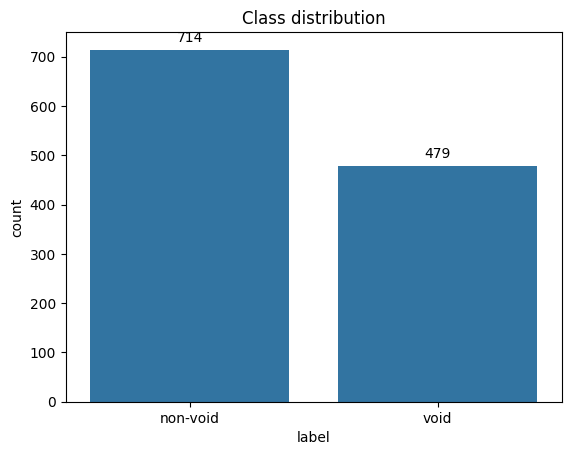

In [74]:
plt.figure()
ax = sns.countplot(x='label',
                   data=features,
                   order=features.label.value_counts().index)

# Manually add value labels
for i, bar in enumerate(ax.patches):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(height)}',
            ha='center', va='bottom')

plt.title('Class distribution')
plt.show()

In [75]:
X = features.drop(columns=['label', 'experiment_id'])
y = features['label']

In [76]:
feature_names = X.columns

In [77]:
X = scale(X)
X

array([[-0.93754405, -1.0369527 ,  1.33186106, ...,  1.85283009,
         1.06178475,  1.04977947],
       [ 0.46641683,  0.26004634,  0.98795548, ..., -0.05288864,
        -0.36890336, -0.36901208],
       [ 0.41070674,  0.72487119,  0.49208157, ...,  1.2777429 ,
         0.05588089,  0.05223997],
       ...,
       [ 0.37223057,  0.12866686,  0.02560613, ...,  0.18639776,
         0.0027297 ,  0.00768945],
       [-0.25469879,  1.80136529, -0.71178978, ..., -0.01909558,
        -0.36200878, -0.36014673],
       [ 0.76595736,  1.51421214, -0.34000901, ..., -0.19339291,
        -0.37560437, -0.37385779]], shape=(1193, 88))

In [78]:
# Should be close to 0 and 1 respectively
# print("Mean:", X.mean(axis=0))
# print("Std:", X.std(axis=0))

#### Perform PCA analysis

In [79]:
pca = PCA(n_components=88)
pca.fit(X)

PCA(n_components=88)

In [80]:
scores = pca.transform(X)
n_components = scores.shape[1]  # Get number of columns dynamically
scores_df = pd.DataFrame(scores, columns=[f'PC{i+1}' for i in range(n_components)])


In [81]:
df_scores = pd.concat([scores_df, y], axis=1)

Retrieve loading values

In [82]:
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=[f'PC{i+1}' for i in range(n_components)], index=feature_names)

Explained variance for each PC

In [83]:
explained_variance = pca.explained_variance_ratio_
other_explained_variance = explained_variance
len(explained_variance)

88

### Scree plot

In [84]:
explained_variance = np.insert(explained_variance, 0, 0)

In [85]:
cumulative_variance = np.cumsum(np.round(explained_variance, decimals=3))


In [86]:
n_components = len(pca.components_)
# pc_df = pd.DataFrame(['','PC1', 'PC2', 'PC3'], columns=['PC'])
pc_df = pd.DataFrame([''] + [f'PC{i+1}' for i in range(n_components)],columns=['PC'])
explained_variance_df = pd.DataFrame(explained_variance, columns=['Explained Variance'])
cumulative_variance_df = pd.DataFrame(cumulative_variance, columns=['Cumulative Variance'])

In [87]:
df_explained_variance = pd.concat([pc_df, explained_variance_df, cumulative_variance_df], axis=1)
# df_explained_variance

In [88]:
fig = px.bar(df_explained_variance, 
             x='PC', y='Explained Variance',
             text='Explained Variance',
             width=800)

fig.update_traces(texttemplate='%{text:.3f}', textposition='outside')
fig.show()

In [89]:
# Find number of components that explain 95% of variance
cumulative_var = np.cumsum(explained_variance[1:])  # Remove the 0 we inserted
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f"Components needed for 95% variance: {n_components_95}")

# # Use this for training
# X_pca = scores_df.iloc[:, :n_components_95]

Components needed for 95% variance: 22


In [90]:
X = features.drop(columns=['label', 'experiment_id'])
# X = features[['acc_x_permutation_entropy', 'acc_x_spectral_entropy', "acc_x_mean"]]
# X_pca = scores_df.iloc[:, :3]
y = features['label']
groups = features['experiment_id']

splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)



In [91]:
def setup_xgboost_with_imbalance_handling(X_train, y_train, use_smote=False, original_scale_weight=1.27):
    """
    Set up XGBoost with appropriate imbalance handling
    """
    if use_smote:
        print("Applying SMOTE...")
        smote = SMOTE(random_state=42)
        X_balanced, y_balanced = smote.fit_resample(X_train, y_train)
        
        # Check if we still need scale_pos_weight
        unique, counts = np.unique(y_balanced, return_counts=True)
        ratio = counts[0] / counts[1]
        
        if abs(ratio - 1.0) > 0.1:
            scale_weight = ratio
            print(f"Post-SMOTE imbalance detected, using scale_pos_weight: {scale_weight:.3f}")
        else:
            scale_weight = None
            print("Classes balanced after SMOTE, not using scale_pos_weight")
    else:
        print("No SMOTE applied, using original scale_pos_weight")
        X_balanced, y_balanced = X_train, y_train
        scale_weight = original_scale_weight
    
    # Configure XGBoost
    xgb_params = {        
        # 'n_estimators':200,
        # 'max_depth':5,
        # 'learning_rate':0.1,
        # 'subsample':0.8,
        # 'colsample_bytree':0.8,
        # 'random_state':42,
        # 'eval_metric':'logloss',
        # 'reg_alpha':0.1,   # L1 regularization
        # 'reg_lambda':1.0,  # L2 regularization
        # 'verbosity':0
    }
    
    if scale_weight is not None:
        xgb_params['scale_pos_weight'] = scale_weight
        
        

    
    model = XGBClassifier(**xgb_params)
    
    return model, X_balanced, y_balanced

In [92]:
model, X_train_final, y_train_final = setup_xgboost_with_imbalance_handling(
                                        X_train, 
                                        y_train,
                                        use_smote=False,  # Switch this as needed
                                        original_scale_weight=1.27
                                    )

No SMOTE applied, using original scale_pos_weight


In [93]:
label_encoder = LabelEncoder()
# Encode y_test and y_train
y_train_encoded = label_encoder.fit_transform(y_train_final) 
y_test_encoded = label_encoder.transform(y_test)

In [94]:
eval_set = [(X_train_final, y_train_encoded), (X_test, y_test_encoded)]
model.fit(X_train_final, y_train_encoded, eval_set=eval_set, verbose=False)

AttributeError: 'super' object has no attribute '__sklearn_tags__'

AttributeError: 'super' object has no attribute '__sklearn_tags__'

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [95]:
# Classification report
y_pred = label_encoder.inverse_transform(model.predict(X_test))
y_pred_prob = model.predict_proba(X_test)
y_pred_labels = label_encoder.inverse_transform(np.argmax(y_pred_prob, axis=1))
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

    non-void       0.69      0.89      0.78       195
        void       0.67      0.34      0.45       122

    accuracy                           0.68       317
   macro avg       0.68      0.62      0.61       317
weighted avg       0.68      0.68      0.65       317



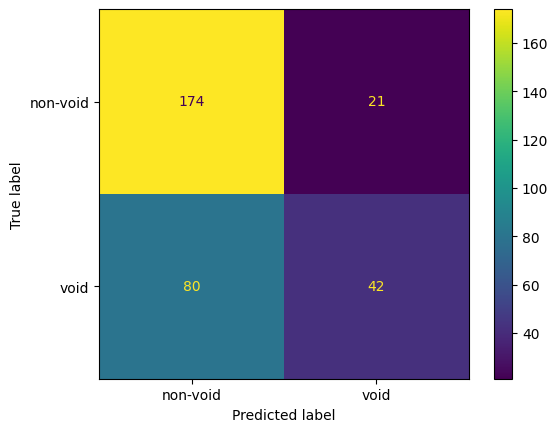

In [96]:

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = ['non-void', 'void'])
cm_display.plot()
# plt.title('3s sliding window, 0.5 overlap, smote')
# plt.savefig('model_plots/two_class_results/cm_3s_0.5_smote.png')
plt.show()


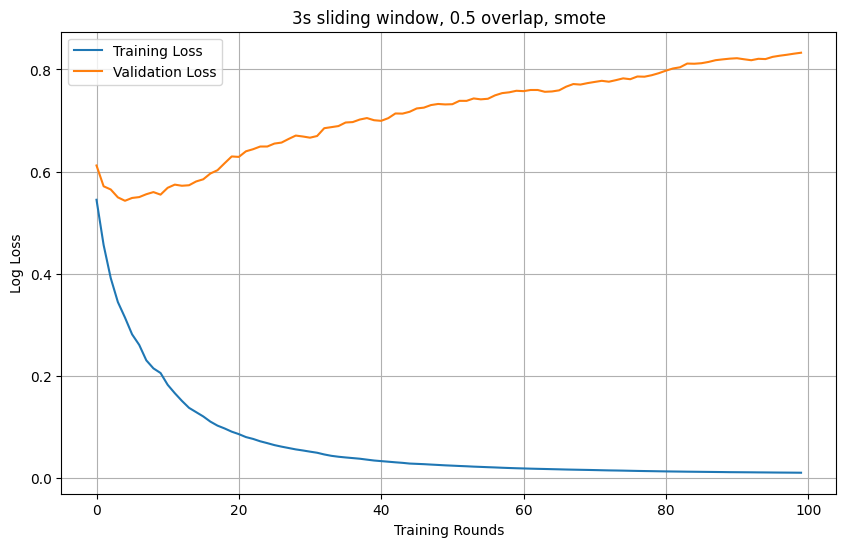

In [97]:
# Retrieve the evaluation results
results = model.evals_result()
train_loss = results['validation_0']['logloss']
test_loss = results['validation_1']['logloss']

# Plot the loss function
plt.figure(figsize=(10, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(test_loss, label='Validation Loss')
plt.xlabel('Training Rounds')
plt.ylabel('Log Loss')
plt.title('3s sliding window, 0.5 overlap, smote')
plt.legend()
plt.grid(True)
# plt.savefig('model_plots/two_class_results/loss_3s_0.5_smote.png')
plt.show()

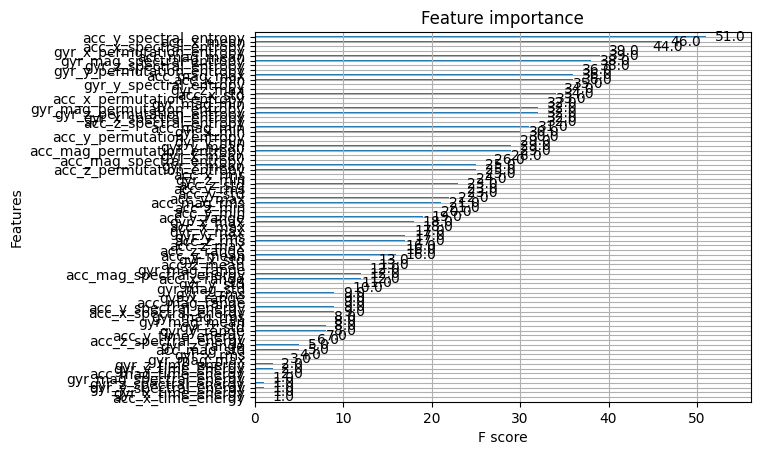

In [98]:
plot_importance(model)
plt.show()

In [99]:
# # Check class distribution after SMOTE
# unique, counts = np.unique(y_train_smote, return_counts=True)
# print(f"After SMOTE: {dict(zip(unique, counts))}")

# # Calculate new ratio (should be close to 1.0 if perfectly balanced)
# new_ratio = counts[0] / counts[1]  # negative/positive
# print(f"New scale_pos_weight should be: {new_ratio}")

In [100]:
# # Encode string labels to integers
# label_encoder = LabelEncoder()

# # use SMOTE data
# y_train_encoded = label_encoder.fit_transform(y_train_smote) # replaced y_train with the y_train_smote

# # y_train_encoded = label_encoder.fit_transform(y_train) 
# y_test_encoded = label_encoder.transform(y_test)



# # Now train XGBoost
# model = XGBClassifier(
#     n_estimators=200,
#     max_depth=5,
#     learning_rate=0.1,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric='logloss',
#     reg_alpha=0.1,   # L1 regularization
#     reg_lambda=1.0,  # L2 regularization
#     # early_stopping_rounds=10,
#     # scale_pos_weight=1.27,  # Adjust based on your imbalance
#     scale_pos_weight=new_ratio if abs(new_ratio - 1.0) > 0.1 else None,
#     verbosity=0
# )

# # eval_set = [(X_train, y_train_encoded), (X_test, y_test_encoded)] 
# # model.fit(X_train, y_train_encoded, eval_set=eval_set, verbose=False)  # Use encoded labels


# # use SMOTE data
# eval_set = [(X_train_smote, y_train_encoded), (X_test, y_test_encoded)] # replaced X_train with the X_train_smote
# model.fit(X_train_smote, y_train_encoded, eval_set=eval_set, verbose=False)  # Use encoded labels